# Chapter 5 — Decision Trees

> *Hands-On Machine Learning with Scikit-Learn, Keras & PyTorch* — Aurélien Géron (2025)

---

In [1]:
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-Learn
from sklearn.datasets import load_iris, make_moons, make_regression
from sklearn.tree import (DecisionTreeClassifier, DecisionTreeRegressor,
                           export_graphviz, plot_tree)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

# Reproducibility
np.random.seed(42)

# Shared data path — works from any chapter subfolder
DATA_PATH = Path('../data')

## Training and Visualizing a Decision Tree

In [10]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[['sepal length (cm)', 'sepal width (cm)']].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [11]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file='iris_tree.dot',
    feature_names=['sepal length (cm)', 'sepal width (cm)'],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

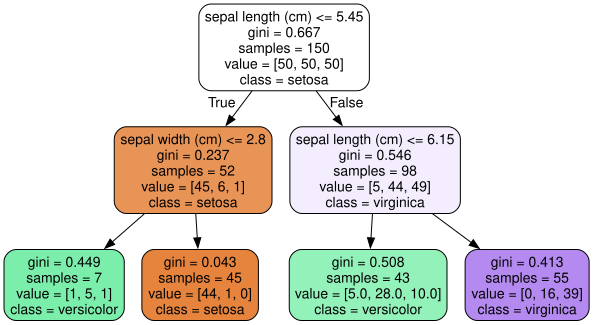

In [12]:
from graphviz import Source

Source.from_file("iris_tree.dot")

## Making Predictions

la gini impurity se calcula como:
$$G = 1 - \sum_{k=1}^{n} p_k^2$$

donde $p_k$ es la proporción de muestras que pertenecen a la clase $k$ en el nodo.
